In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Brent Oil Prices
df = pd.read_csv('../data/brentoilprices.csv')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True) # Ensure date parsing is correct
df = df.sort_values('Date')

# Load Events
events_df = pd.read_csv('../data/events.csv')
events_df['Date'] = pd.to_datetime(events_df['Date'])

print(f"Data ranges from {df['Date'].min()} to {df['Date'].max()}")

C:\Users\HP\AppData\Local\Temp\ipykernel_2868\3477552872.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True) # Ensure date parsing is correct


Data ranges from 1987-05-20 00:00:00 to 2022-11-14 00:00:00


In [1]:
pip install matplotlib seaborn pandas


  Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pandas-3.0.0-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp314-cp314-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp314-cp314-win_amd64.whl.metadata (6.4 kB)
  Using cached numpy-2.4.2-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached pillow-12.1.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached pandas-3.0.0-cp314-cp314-win_amd64.whl (9.9 MB)
Using cached contourpy-1.3.3-cp314-cp3


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


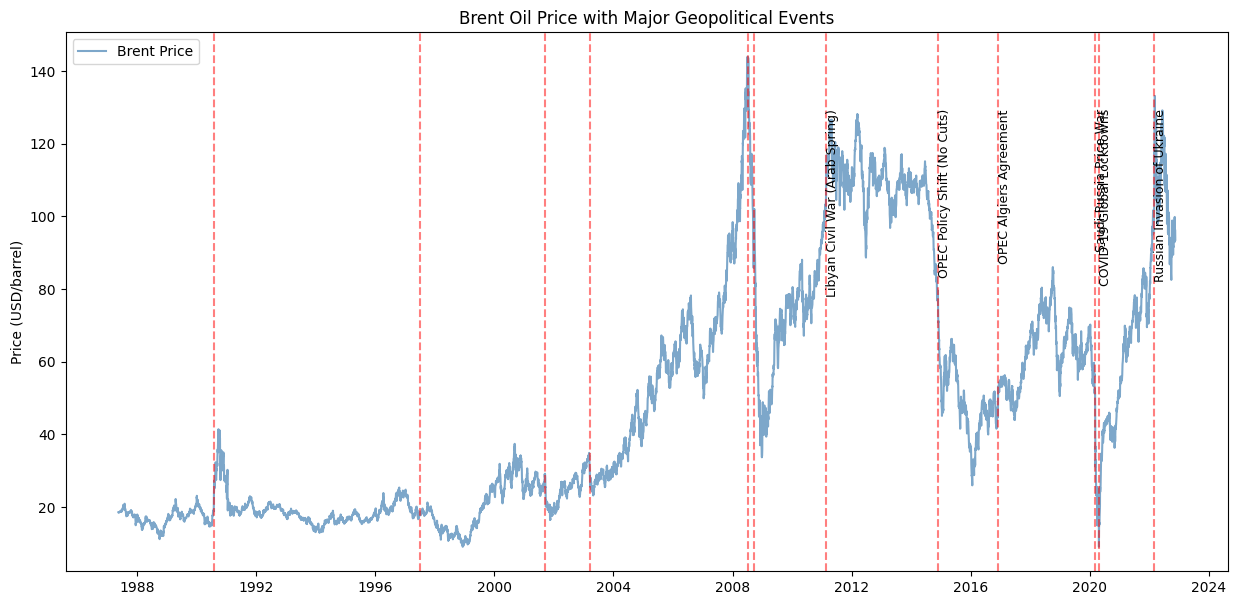

In [3]:
plt.figure(figsize=(15, 7))
plt.plot(df['Date'], df['Price'], color='steelblue', alpha=0.7, label='Brent Price')

# Overlay the events as vertical lines
for i, row in events_df.iterrows():
    plt.axvline(x=row['Date'], color='red', linestyle='--', alpha=0.5)
    # Add labels to the most recent/significant events to avoid clutter
    if row['Date'] > pd.to_datetime('2010-01-01'):
        plt.text(row['Date'], df['Price'].max()*0.9, row['Event'], 
                 rotation=90, verticalalignment='top', fontsize=9)

plt.title('Brent Oil Price with Major Geopolitical Events')
plt.ylabel('Price (USD/barrel)')
plt.legend()
plt.show()

ADF Statistic (Price): -1.9938560113924664
p-value: 0.2892735048934034


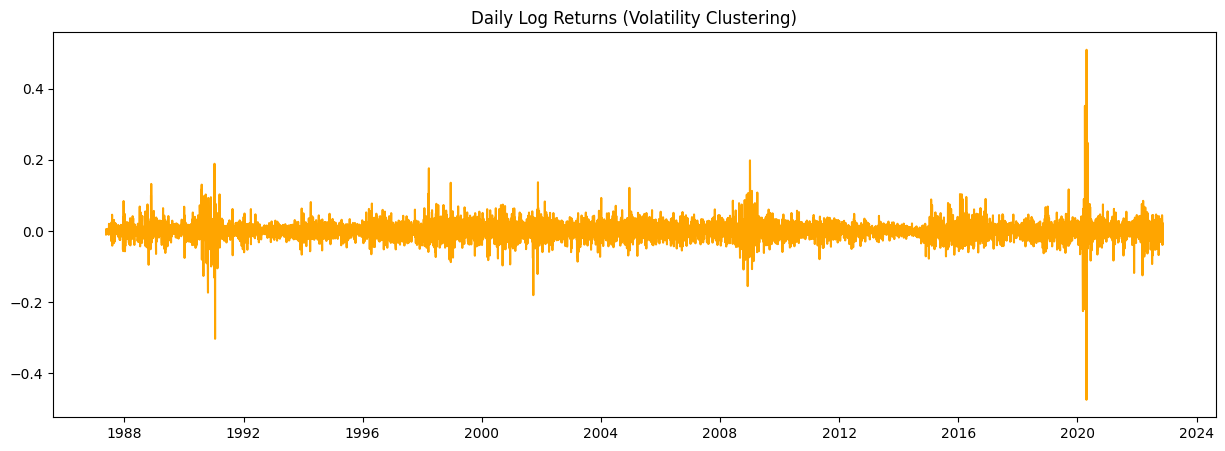

In [6]:
from statsmodels.tsa.stattools import adfuller

# Calculate daily returns
df['Returns'] = df['Price'].pct_change().dropna()

# Check Stationarity
result = adfuller(df['Price'].dropna())
print(f'ADF Statistic (Price): {result[0]}')
print(f'p-value: {result[1]}') # If > 0.05, it's non-stationary

# Plot Returns (Volatility)
plt.figure(figsize=(15, 5))
plt.plot(df['Date'], df['Returns'], color='orange')
plt.title('Daily Log Returns (Volatility Clustering)')
plt.show()

In [5]:
pip install statsmodels

  Using cached statsmodels-0.14.6-cp314-cp314-win_amd64.whl.metadata (9.8 kB)
  Using cached scipy-1.17.0-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
Using cached statsmodels-0.14.6-cp314-cp314-win_amd64.whl (9.6 MB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)
Using cached scipy-1.17.0-cp314-cp314-win_amd64.whl (37.1 MB)

   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   -------------------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Task 2: Bayesian Modeling.

In [8]:
import pymc as pm
import numpy as np
import arviz as az

# 1. Prepare data (Focusing on a recent window for speed)
# Let's look at data from 2018 onwards to see the COVID/Ukraine shift
recent_df = df[df['Date'] > '2018-01-01'].copy().reset_index()
price_data = recent_df['Price'].values
n_data = len(price_data)
idx = np.arange(n_data)

with pm.Model() as change_point_model:
    # Priors for the two regimes
    # We expect prices to be roughly around the mean of the data
    mu_1 = pm.Normal("mu_1", mu=price_data.mean(), sigma=10)
    mu_2 = pm.Normal("mu_2", mu=price_data.mean(), sigma=10)
    
    # Prior for the standard deviation (volatility)
    sigma = pm.HalfNormal("sigma", sigma=5)
    
    # Prior for the switch point (Tau)
    # It can be any day from the start to the end of our dataset
    tau = pm.DiscreteUniform("tau", lower=0, upper=n_data - 1)
    
    # The Switch logic: if index < tau, use mu_1, else mu_2
    mu_ = pm.math.switch(tau > idx, mu_1, mu_2)
    
    # Likelihood (The actual observation)
    observation = pm.Normal("obs", mu=mu_, sigma=sigma, observed=price_data)

    # 2. Sampling (MCMC)
    trace = pm.sample(1000, tune=1000, return_inferencedata=True)

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
d:\10 Academy\week11\birhan-energies-analysis\venv\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>NUTS: [mu_1, mu_2, sigma]
>Metropolis: [tau]


d:\10 Academy\week11\birhan-energies-analysis\venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 5747 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [7]:
pip install pymc numpy arviz

  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached setuptools-82.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached filelock-3.20.3-py3-none-any.whl.metadata (2.1 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/552.5 kB ? eta -:--:--
   ---------------------------------------- 0.0/552.5 kB ? eta -:--:--
   ------------------ --------------------- 262.1/552.5 kB ? eta -:--:--
   ------------------------------------ - 524.3/552.5 kB 874.3 kB/s eta 0:00:01
   ------------------------------------ - 524.3/552.5 kB 874.3 kB/s eta 0:00:01
   ---------------------------------------- 552.5/552.5 kB 439.9 kB/s  0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:-

  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
